# p0 — Model Cohort Assignment & Architecture Visualization

**Purpose (optional notebook):** Assign each model in `models.parquet` to a quarterly cohort based on its Hub upload date, then visualize how the architecture mix evolves across cohorts.

**What this notebook covers:**
1. Derive a `cohort` column (e.g. `Q3-2024`) from the raw `Upload To Hub Date` field
2. Plot absolute model counts and percentage share by architecture family per cohort

**Output:** `architecture_by_cohort.png` — used to visually verify that no single cohort is dominated by an unusual architecture mix.

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

## 1. Assign Quarterly Cohorts

`Upload To Hub Date` is parsed to a datetime, then mapped to a quarter string (`Q1`–`Q4` + year). Models with a missing or unparseable date are labelled `Unknown` and excluded from cohort-level analyses.

In [24]:
df = pd.read_parquet("../data_raw/models.parquet")


def assign_quarter(dt):
    """Map a datetime to a cohort string like 'Q3-2024'."""
    if pd.isna(dt):
        return "Unknown"
    q = (dt.month - 1) // 3 + 1
    return f"Q{q}-{dt.year}"


df["release_date"] = pd.to_datetime(df["Upload To Hub Date"], errors="coerce")
df["cohort"] = df["release_date"].apply(assign_quarter)

print(f"{len(df):,} models total")
print(df["cohort"].value_counts().sort_index())

# We already provide output in this repo, uncomment this if you want to save again.
# df.to_parquet("../data_clean/models.parquet", index=False)

4,576 models total
cohort
Q1-2022      17
Q1-2023      14
Q1-2024     145
Q1-2025    1472
Q2-2022       8
Q2-2023      26
Q2-2024     465
Q3-2022       1
Q3-2023      36
Q3-2024     663
Q4-2022       8
Q4-2023      75
Q4-2024    1116
Unknown     530
Name: count, dtype: int64


## 2. Architecture Mix by Cohort

Two stacked bar charts are produced side-by-side:
- **Top panel** — absolute model counts, to show how the leaderboard grew over time
- **Bottom panel** — percentage share, to reveal structural shifts in architecture composition independent of total volume

Only the top-8 architecture families by total count are shown; remaining architectures are implicitly grouped into the unlabelled remainder.

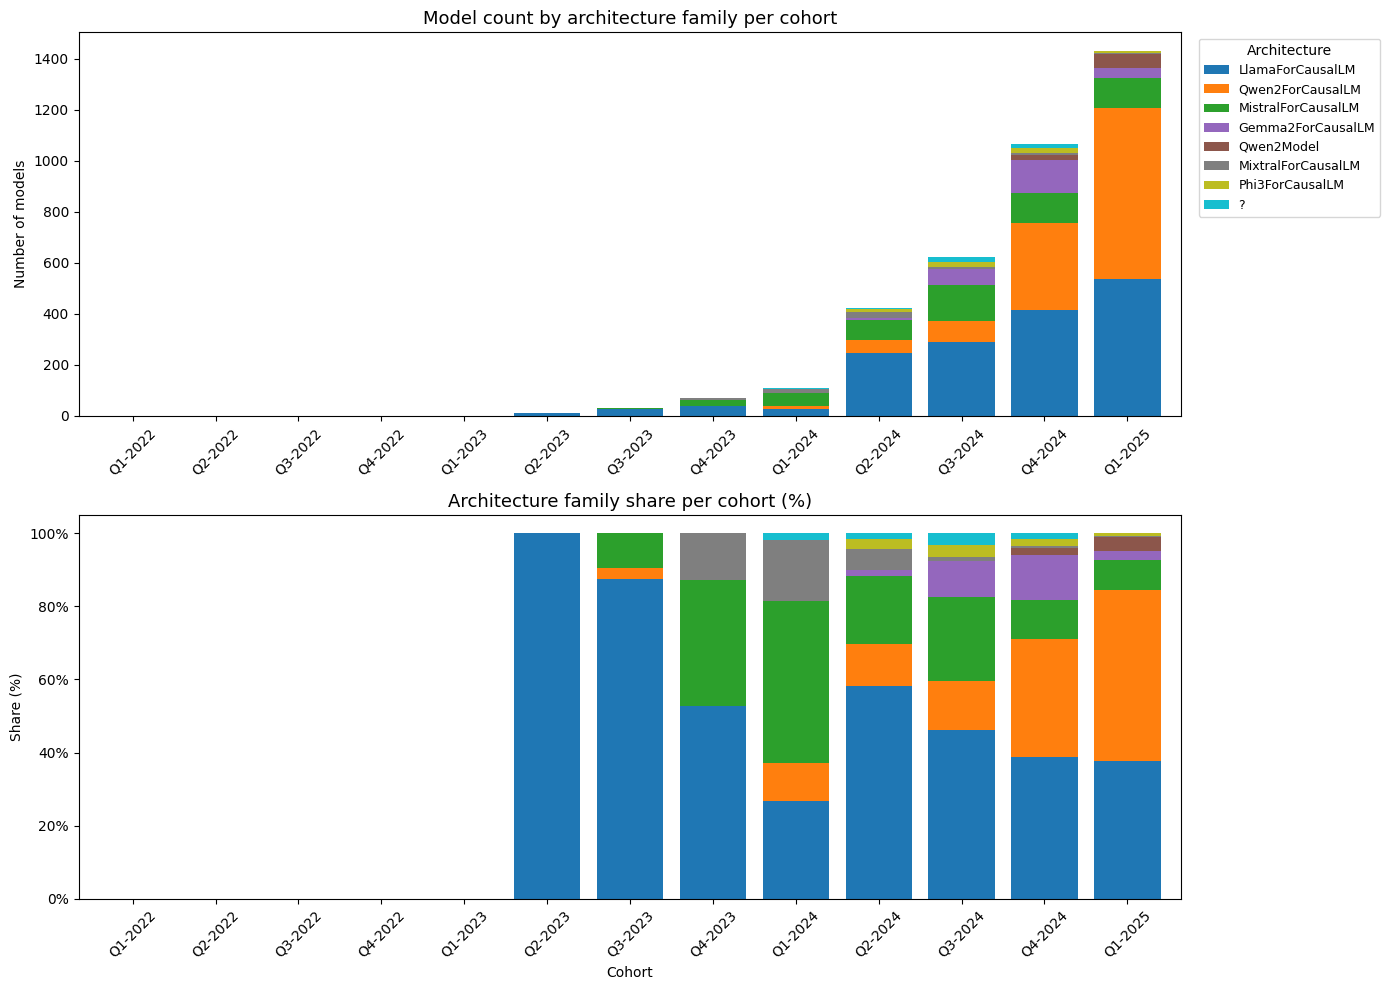

In [25]:
def cohort_sort_key(cohort):
    """Sort cohort strings (e.g. 'Q3-2024') chronologically."""
    if cohort == "Unknown":
        return (9999, 9)
    q, year = cohort.split("-")
    return (int(year), int(q[1]))


dist = (
    df[df["cohort"] != "Unknown"]
    .groupby(["cohort", "Architecture"])
    .size()
    .reset_index(name="count")
)

pivot = dist.pivot_table(
    index="cohort", columns="Architecture", values="count", fill_value=0
)
pivot = pivot.loc[sorted(pivot.index, key=cohort_sort_key)]

top_families = pivot.sum().sort_values(ascending=False).head(8).index
pivot_plot   = pivot[top_families]
pivot_pct    = pivot_plot.div(pivot_plot.sum(axis=1), axis=0).mul(100)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

pivot_plot.plot(
    kind="bar", stacked=True, ax=axes[0], colormap="tab10", width=0.8
)
axes[0].set_title("Model count by architecture family per cohort", fontsize=13)
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of models")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Architecture", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

pivot_pct.plot(
    kind="bar", stacked=True, ax=axes[1], colormap="tab10", width=0.8, legend=False
)
axes[1].set_title("Architecture family share per cohort (%)", fontsize=13)
axes[1].set_xlabel("Cohort")
axes[1].set_ylabel("Share (%)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()